# Logistics Delivery Analysis

Análisis exploratorio de una muestra anonimizada de entregas y clientes.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("dataset_clientes_anonimizado.csv")
df.head()


Saving dataset_clientes_anonimizado.csv to dataset_clientes_anonimizado.csv


,latitud,longitud,barrio,cantidad_entregas,segmento
0,-34.609342,-58.412825,BALVANERA,2,baja
1,-34.786565,-58.152055,Sin dato,6,media
2,-34.464050,-58.760690,Sin dato,4,baja
3,-34.598733,-58.373635,SAN NICOLAS,1,baja
4,-34.610302,-58.427572,ALMAGRO,2,baja


In [11]:
print("Dimensiones:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)


Dimensiones: (3000, 5)

Columnas: ['latitud', 'longitud', 'barrio', 'cantidad_entregas', 'segmento']

Tipos de datos:
latitud              float64
longitud             float64
barrio                object
cantidad_entregas      int64
segmento              object
dtype: object


In [12]:
df["barrio"] = df["barrio"].fillna("Sin dato")
df["segmento"] = df["segmento"].fillna("sin dato").astype(str).str.strip().str.lower()
df["cantidad_entregas"] = pd.to_numeric(df["cantidad_entregas"], errors="coerce")
df.head()


,latitud,longitud,barrio,cantidad_entregas,segmento
0,-34.609342,-58.412825,BALVANERA,2,baja
1,-34.786565,-58.152055,Sin dato,6,media
2,-34.464050,-58.760690,Sin dato,4,baja
3,-34.598733,-58.373635,SAN NICOLAS,1,baja
4,-34.610302,-58.427572,ALMAGRO,2,baja


## Distribución de clientes por segmento

In [13]:
segmentos = df["segmento"].value_counts().reset_index()
segmentos.columns = ["segmento", "clientes"]
segmentos


,segmento,clientes
0,baja,2628
1,alta,204
2,media,168


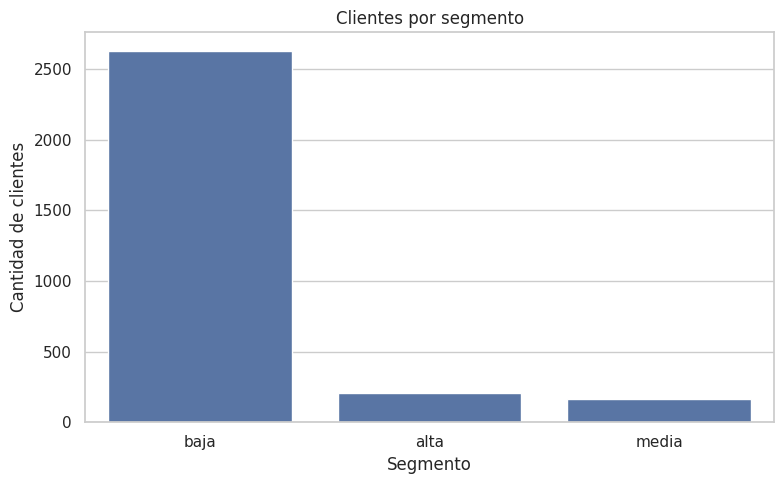

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=segmentos, x="segmento", y="clientes")
plt.title("Clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()


## Top barrios por cantidad de clientes

In [15]:
top_barrios = (
    df.groupby("barrio")
      .size()
      .reset_index(name="clientes")
      .sort_values("clientes", ascending=False)
)
top_barrios.head(10)


,barrio,clientes
33,Sin dato,1502
20,PALERMO,145
7,CABALLITO,107
4,BELGRANO,87
1,ALMAGRO,79
27,RECOLETA,79
48,VILLA URQUIZA,74
12,FLORES,71
2,BALVANERA,57
36,VILLA CRESPO,49


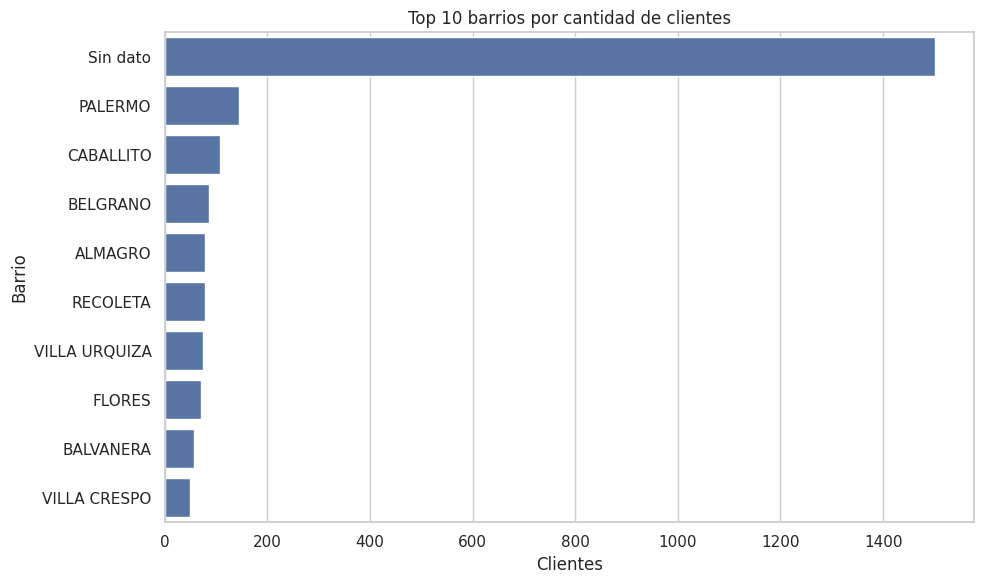

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_barrios.head(10), y="barrio", x="clientes")
plt.title("Top 10 barrios por cantidad de clientes")
plt.xlabel("Clientes")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()


## Top barrios por cantidad total de entregas

In [17]:
top_entregas = (
    df.groupby("barrio")["cantidad_entregas"]
      .sum()
      .reset_index()
      .sort_values("cantidad_entregas", ascending=False)
)
top_entregas.head(10)


,barrio,cantidad_entregas
33,Sin dato,5004
20,PALERMO,441
7,CABALLITO,356
4,BELGRANO,282
27,RECOLETA,238
48,VILLA URQUIZA,234
1,ALMAGRO,222
12,FLORES,189
2,BALVANERA,139
37,VILLA DEL PARQUE,137


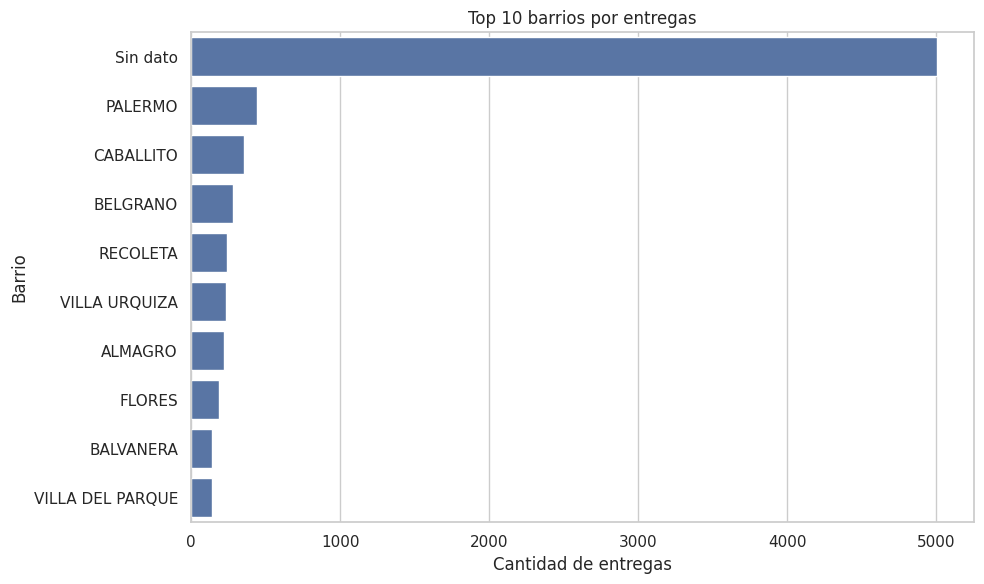

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_entregas.head(10), y="barrio", x="cantidad_entregas")
plt.title("Top 10 barrios por entregas")
plt.xlabel("Cantidad de entregas")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()


## Distribución de cantidad de entregas

In [19]:
df["cantidad_entregas"].describe()


,cantidad_entregas
count,3000.000000
mean,3.085667
std,4.411593
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,50.000000


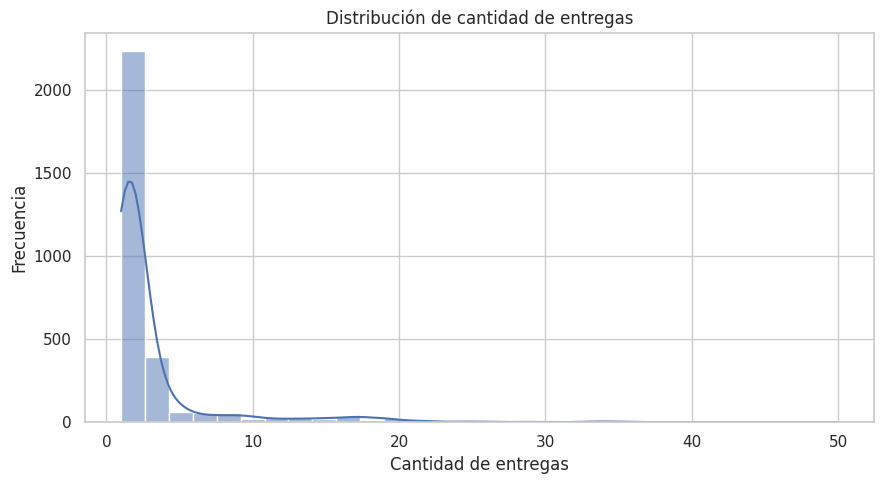

In [20]:
plt.figure(figsize=(9,5))
sns.histplot(df["cantidad_entregas"].dropna(), bins=30, kde=True)
plt.title("Distribución de cantidad de entregas")
plt.xlabel("Cantidad de entregas")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## Visualización geográfica simple

In [21]:
df_geo = df.dropna(subset=["latitud", "longitud"]).copy()
print("Registros con coordenadas:", len(df_geo))


Registros con coordenadas: 3000


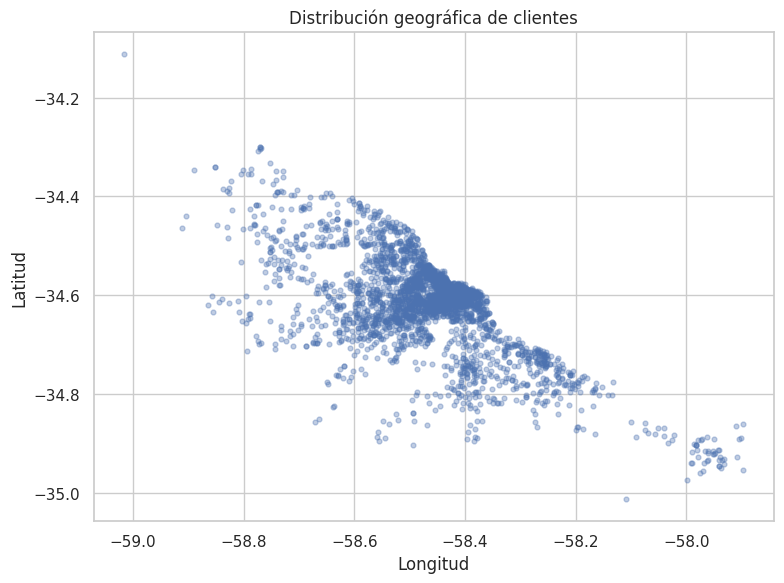

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(df_geo["longitud"], df_geo["latitud"], alpha=0.35, s=12)
plt.title("Distribución geográfica de clientes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()


## Insights

- La distribución de clientes muestra una clara concentración geográfica, lo que permite definir zonas de reparto más eficientes.
- La segmentación por frecuencia y volumen facilita priorizar clientes estratégicos y optimizar la planificación operativa.
- Existen barrios con mayor peso operativo, lo que permite enfocar recursos y ajustar la logística según la demanda real.

- La recurrencia de pedidos en determinadas zonas sugiere que es posible agrupar entregas y mejorar la eficiencia de rutas.
- La concentración geográfica observada abre la posibilidad de implementar estrategias de microzonificación para optimizar costos y tiempos de entrega.